In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
shape = 100, 30

In [3]:
np.random.seed(42)

In [4]:
df = pd.DataFrame(np.random.randint(1, 200, shape))

Q1.	Replace all the values with NA in the dataset defined between [10,60]. Print the count of NAss in each row and each column. 

In [5]:
df = df.mask((df >= 10) & (df <= 60) , np.nan)

print("NA count per row:", df.isna().sum(axis=1))
print("NA count per column:", df.isna().sum(axis=0))

NA count per row: 0      7
1     11
2      9
3      8
4      9
      ..
95    11
96     9
97     6
98     9
99    10
Length: 100, dtype: int64
NA count per column: 0     27
1     18
2     24
3     30
4     23
5     26
6     25
7     29
8     23
9     27
10    34
11    27
12    28
13    28
14    28
15    28
16    21
17    31
18    21
19    21
20    25
21    29
22    32
23    21
24    30
25    20
26    29
27    30
28    19
29    26
dtype: int64


Q2.	Replace all the NA values with the average of the column values. 

In [6]:
df.fillna(df.mean(axis=0) , inplace=True)
df

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,103.000000,180.000000,93.000000,118.685714,107.000000,72.000000,189.000000,116.492958,103.000000,122.000000,...,88.00,158.000000,119.397059,130.000000,192.000000,188.0000,130.859155,161.000000,126.518519,116.675676
1,89.000000,125.426829,124.486842,170.000000,188.000000,123.918919,190.000000,190.000000,175.000000,190.000000,...,116.64,132.000000,89.000000,122.696203,121.957143,9.0000,90.000000,122.342857,130.000000,84.000000
2,92.000000,111.000000,188.000000,199.000000,172.000000,8.000000,175.000000,116.492958,81.000000,164.000000,...,146.00,122.507042,162.000000,190.000000,121.957143,95.0000,130.859155,122.342857,190.000000,116.675676
3,82.000000,111.000000,124.486842,118.685714,154.000000,188.000000,124.000000,116.492958,157.000000,119.123288,...,81.00,136.000000,163.000000,163.000000,121.957143,123.0000,5.000000,122.342857,126.518519,135.000000
4,72.000000,125.426829,162.000000,118.685714,127.571429,151.000000,62.000000,116.492958,99.000000,172.000000,...,116.64,137.000000,119.397059,90.000000,121.957143,124.0000,179.000000,63.000000,96.000000,116.675676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,117.876712,125.426829,124.486842,118.685714,168.000000,146.000000,183.000000,153.000000,129.207792,78.000000,...,149.00,122.000000,119.397059,119.000000,121.957143,120.8875,175.000000,122.342857,149.000000,141.000000
96,149.000000,126.000000,136.000000,118.685714,104.000000,135.000000,151.000000,86.000000,150.000000,89.000000,...,151.00,88.000000,119.397059,122.696203,171.000000,165.0000,189.000000,97.000000,184.000000,3.000000
97,191.000000,118.000000,124.486842,118.685714,157.000000,123.918919,124.733333,108.000000,111.000000,119.123288,...,3.00,193.000000,132.000000,104.000000,64.000000,106.0000,98.000000,122.342857,149.000000,128.000000
98,117.876712,155.000000,66.000000,169.000000,112.000000,123.918919,137.000000,164.000000,86.000000,90.000000,...,144.00,70.000000,119.397059,101.000000,186.000000,132.0000,111.000000,125.000000,132.000000,116.675676


Q3.	Plot heat map.

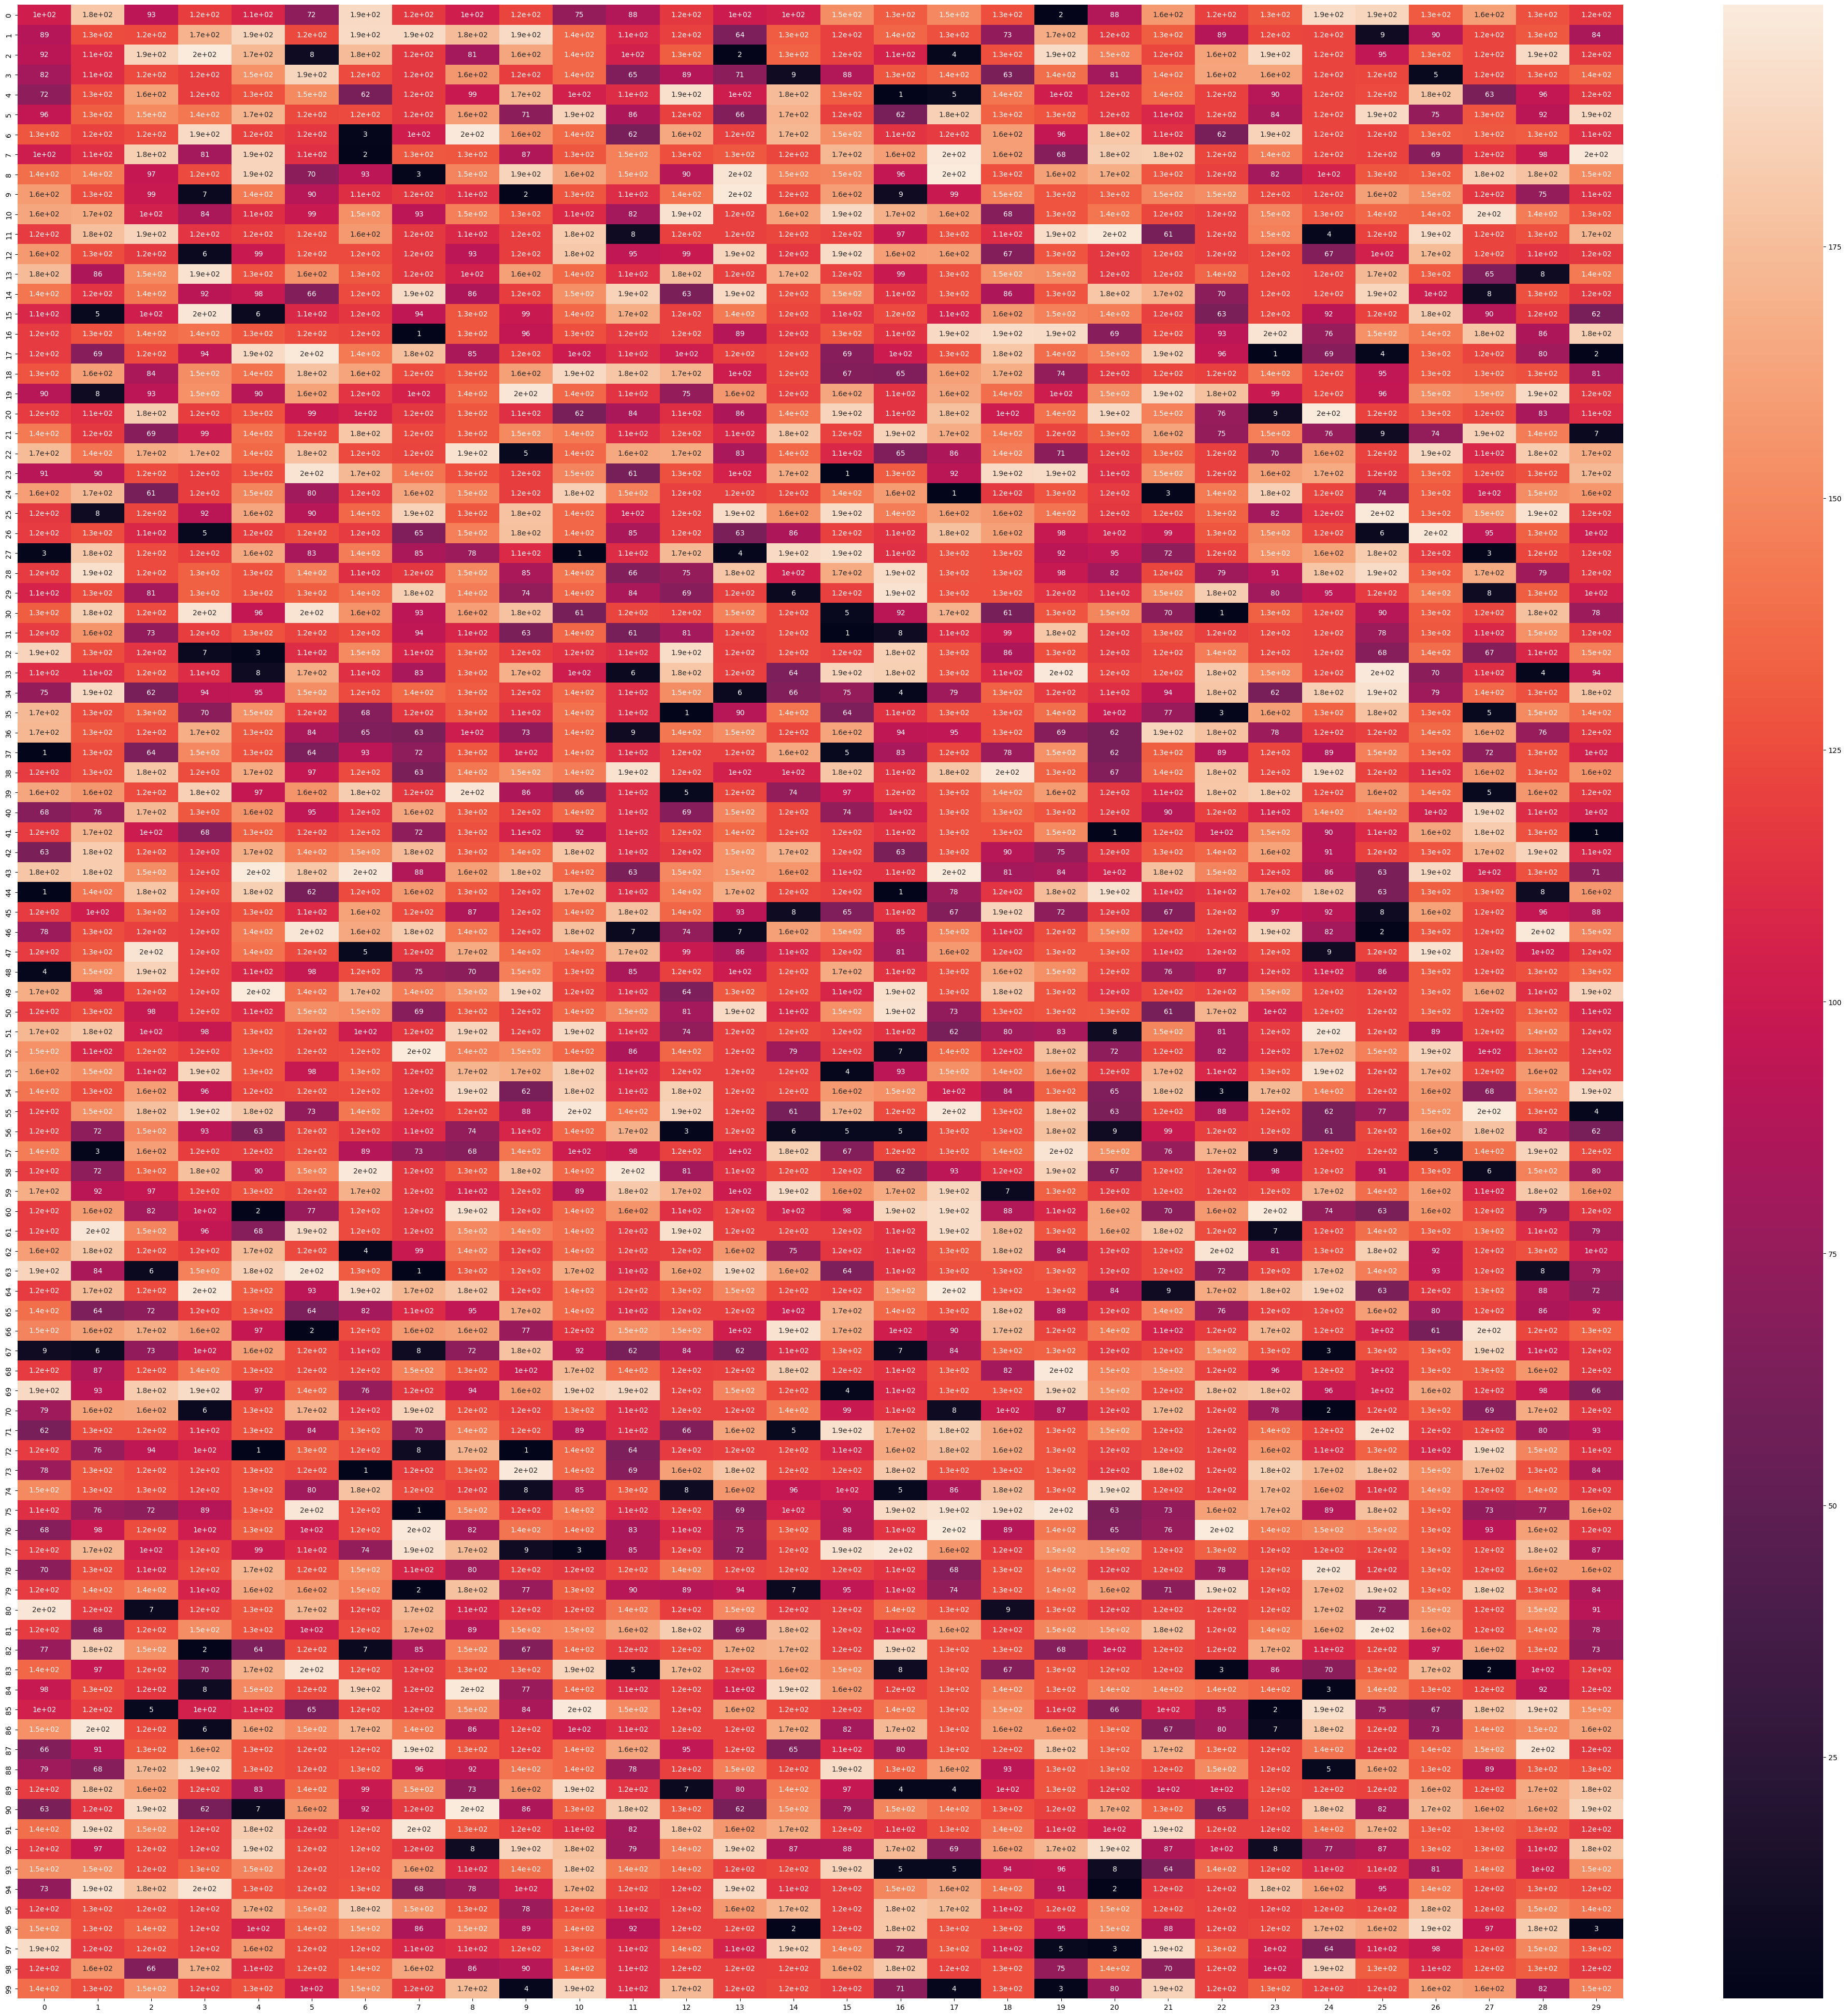

In [7]:
plt.figure(figsize=(50,50))

sns.heatmap(df , annot=True)
plt.show()

Q4.	Count the number of columns having correlation <=0.7 

In [8]:
corr = df.corr()
count = (corr <= 0.7).any(axis=0).sum()

count

np.int64(30)

Q5.	Normalize each column in the dataset between 0 and 10. 

In [9]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 10))

normdata = pd.DataFrame(scaler.fit_transform(df))

In [10]:
normdata.head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,5.230769,9.170984,4.631579,5.923133,5.353535,3.589744,9.543147,5.832978,4.973822,6.142132,...,4.438776,8.157895,5.979649,6.515152,9.644670,9.441624,6.555164,8.071066,6.348110,5.871862
1,4.512821,6.343359,6.288781,8.527919,9.444444,6.252252,9.593909,9.545455,8.743455,9.593909,...,5.900000,6.789474,4.444444,6.146273,6.089195,0.355330,4.427083,6.108774,6.528497,4.213198
2,4.666667,5.595855,9.631579,10.000000,8.636364,0.307692,8.832487,5.832978,3.821990,8.274112,...,7.397959,6.289844,8.131313,9.545455,6.089195,4.720812,6.555164,6.108774,9.637306,5.871862
3,4.153846,5.595855,6.288781,5.923133,7.727273,9.538462,6.243655,5.832978,7.801047,5.996106,...,4.081633,7.000000,8.181818,8.181818,6.089195,6.142132,0.000000,6.108774,6.348110,6.802030
4,3.641026,6.343359,8.263158,5.923133,6.392496,7.641026,3.096447,5.832978,4.764398,8.680203,...,5.900000,7.052632,5.979649,4.494949,6.089195,6.192893,9.062500,3.096447,4.766839,5.871862


Q6.	Replace all the values in the dataset with 0 if value <=5 else with 1. 4. Visualizing the distribution of a dataset. 

In [11]:
def fix_val(x):
    if x <= 5:
        return 0
    else: 
        return 1.4

In [12]:
normdata.map(fix_val)

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,1.4,1.4,0.0,1.4,1.4,0.0,1.4,1.4,0.0,1.4,...,0.0,1.4,1.4,1.4,1.4,1.4,1.4,1.4,1.4,1.4
1,0.0,1.4,1.4,1.4,1.4,1.4,1.4,1.4,1.4,1.4,...,1.4,1.4,0.0,1.4,1.4,0.0,0.0,1.4,1.4,0.0
2,0.0,1.4,1.4,1.4,1.4,0.0,1.4,1.4,0.0,1.4,...,1.4,1.4,1.4,1.4,1.4,0.0,1.4,1.4,1.4,1.4
3,0.0,1.4,1.4,1.4,1.4,1.4,1.4,1.4,1.4,1.4,...,0.0,1.4,1.4,1.4,1.4,1.4,0.0,1.4,1.4,1.4
4,0.0,1.4,1.4,1.4,1.4,1.4,0.0,1.4,0.0,1.4,...,1.4,1.4,1.4,0.0,1.4,1.4,1.4,0.0,0.0,1.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1.4,1.4,1.4,1.4,1.4,1.4,1.4,1.4,1.4,0.0,...,1.4,1.4,1.4,1.4,1.4,1.4,1.4,1.4,1.4,1.4
96,1.4,1.4,1.4,1.4,1.4,1.4,1.4,0.0,1.4,0.0,...,1.4,0.0,1.4,1.4,1.4,1.4,1.4,0.0,1.4,0.0
97,1.4,1.4,1.4,1.4,1.4,1.4,1.4,1.4,1.4,1.4,...,0.0,1.4,1.4,1.4,0.0,1.4,0.0,1.4,1.4,1.4
98,1.4,1.4,0.0,1.4,1.4,1.4,1.4,1.4,0.0,0.0,...,1.4,0.0,1.4,1.4,1.4,1.4,1.4,1.4,1.4,1.4
